In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Problem Statement
- Online courses suffer from dropout rates of 60–80%. An EdTech platform needs to identify at-risk students early — at the 3-week mark — so tutors can intervene before a student quietly withdraws. This project builds an AI-powered early warning system using the OULAD
# Data Details
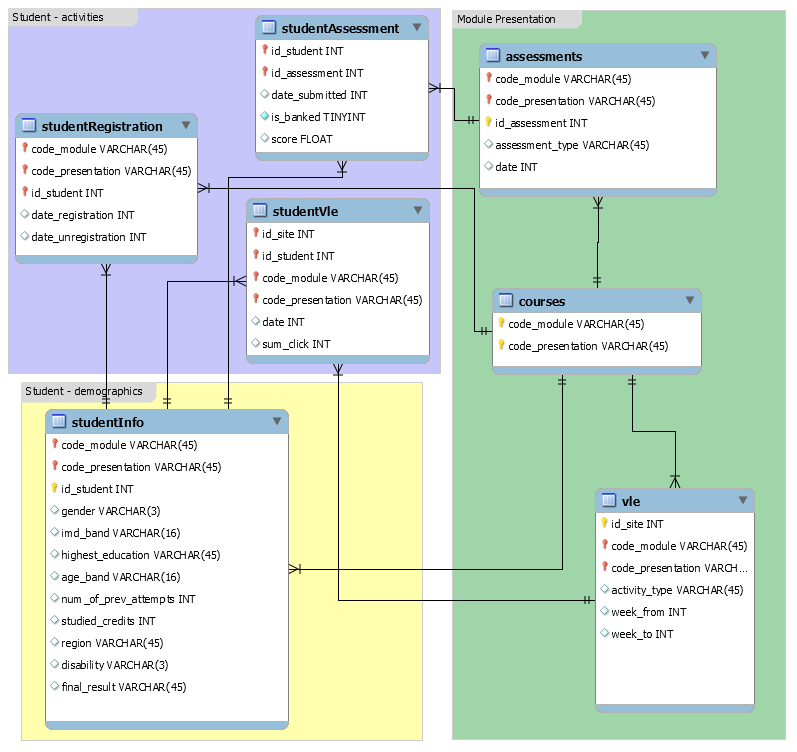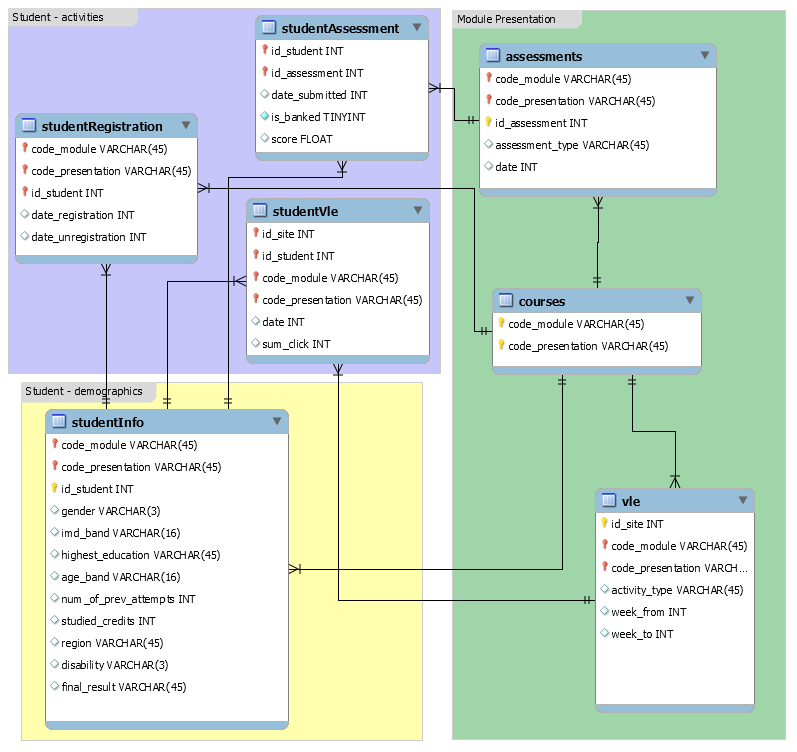

Open University Learning Analytics Dataset (OULAD). It contains data about courses, students and their interactions with Virtual Learning Environment (VLE) for seven selected courses (called modules).


# Objectives
- Filter to module BBB, presentation 2014J
- Join all 4 tables into one dataframe
- - studentVle
  - studentInfo
  - vle
  - studentRegistration 
- Encode target variable at_risk with written justification

# Table 1 Student Info

- code_module - an identification code for a module on which the student is registered.
- code_presentation - the identification code of the presentation during which the student is registered on the module.
- id_student - a unique identification number for the student.
- gender - the student's gender.
- region - identifies the geographic region, where the student lived while taking the module-presentation.
- highest_education - highest student education level on entry to the module presentation.
- imd_band - specifies the Index of Multiple Depravation band of the place where the student lived during the module-presentation.
- age_band - band of the student's age.
- num_of_prev_attempts - the number times the student has attempted this module.
- studied_credits - the total number of credits for the modules the student is currently studying.
- disability - indicates whether the student has declared a disability.
- final_result - student's final result in the module-presentation.

In [2]:
data_assess = pd.read_csv("anonymisedData/studentInfo.csv")


In [3]:
data_assess.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   code_module           32593 non-null  object
 1   code_presentation     32593 non-null  object
 2   id_student            32593 non-null  int64 
 3   gender                32593 non-null  object
 4   region                32593 non-null  object
 5   highest_education     32593 non-null  object
 6   imd_band              31482 non-null  object
 7   age_band              32593 non-null  object
 8   num_of_prev_attempts  32593 non-null  int64 
 9   studied_credits       32593 non-null  int64 
 10  disability            32593 non-null  object
 11  final_result          32593 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.0+ MB


In [4]:
data_assess.shape

(32593, 12)

In [5]:
data_assess.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [6]:
data_assess.isnull().sum()

code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
dtype: int64

the above shows us that null values exist in the imd_band
- it is ~3% of total values that are null

In [7]:
data_assess["imd_band"].value_counts()

imd_band
20-30%     3654
30-40%     3539
10-20      3516
0-10%      3311
40-50%     3256
50-60%     3124
60-70%     2905
70-80%     2879
80-90%     2762
90-100%    2536
Name: count, dtype: int64

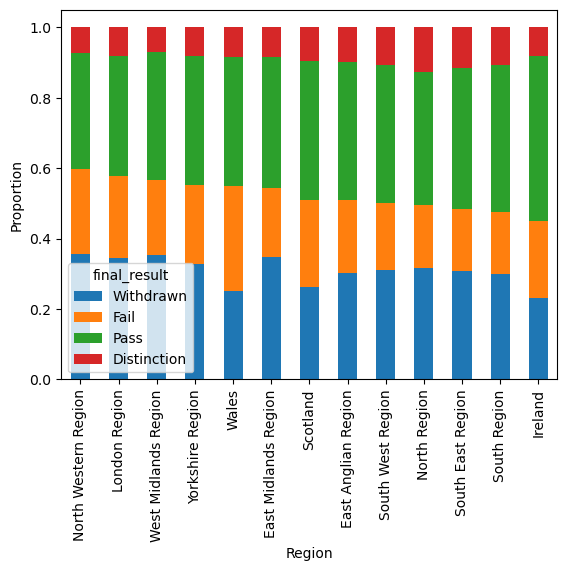

In [8]:
table = pd.crosstab(
    data_assess['region'],
    data_assess['final_result'],
    normalize='index'
)

table = table[['Withdrawn', 'Fail', 'Pass', 'Distinction']]

table = table.loc[
    (table['Withdrawn'] + table['Fail'])
    .sort_values(ascending=False)
    .index
]

table.plot(kind='bar', stacked=True)

plt.xlabel('Region')
plt.ylabel('Proportion')
plt.show()

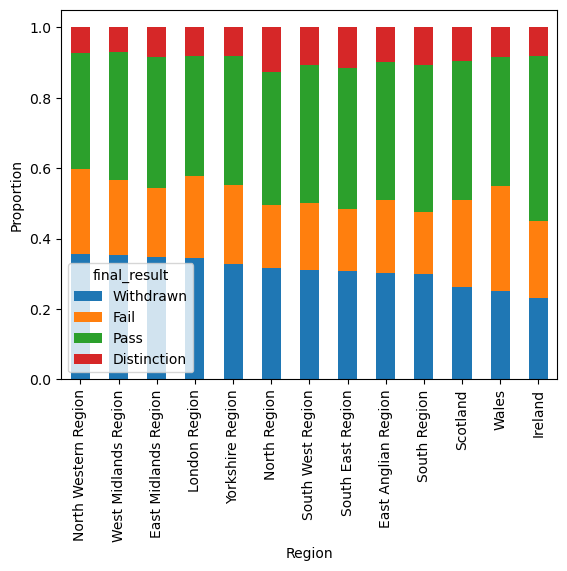

In [9]:
table = pd.crosstab(
    data_assess['region'],
    data_assess['final_result'],
    normalize='index'
)

table = table[['Withdrawn', 'Fail', 'Pass', 'Distinction']]

table = table.loc[
    (table['Withdrawn'])
    .sort_values(ascending=False)
    .index
]

table.plot(kind='bar', stacked=True)

plt.xlabel('Region')
plt.ylabel('Proportion')
plt.show()

In [10]:
imd_mapping = {
    '0-10%': 0,
    '10-20': 1,
    '20-30%': 2,
    '30-40%': 3,
    '40-50%': 4,
    '50-60%': 5,
    '60-70%': 6,
    '70-80%': 7,
    '80-90%': 8,
    '90-100%': 9
}
data_assess['imd_num'] = data_assess['imd_band'].map(imd_mapping)

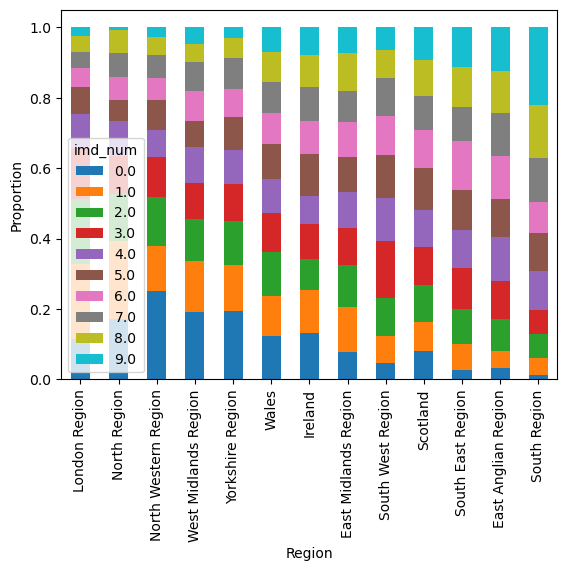

In [11]:
table = pd.crosstab(
    data_assess['region'],data_assess['imd_num'],
    normalize='index'
)

table = table.loc[
    (table[0] + table[1] + table[2] + table[3] )
    .sort_values(ascending=False)
    .index
]



table.plot(
    kind='bar',
    stacked=True
)

plt.xlabel('Region')
plt.ylabel('Proportion')
plt.show()

From the above graphs we can see that Region affects result and so does Imd and since the imd|result and region|result graph dont entirely match we can conclude that region may provide additional info with regards to academic success 

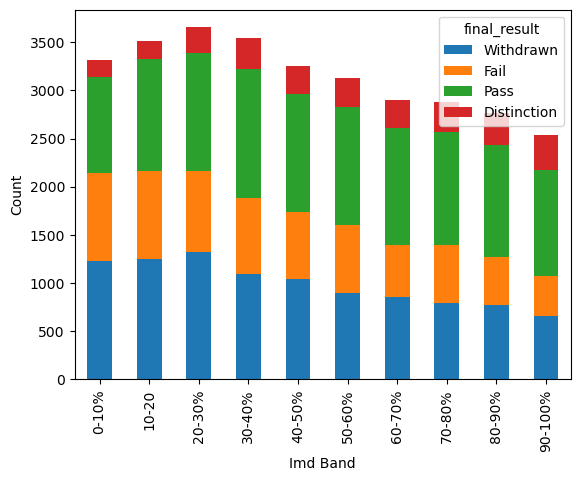

In [12]:
table = pd.crosstab(
    data_assess['imd_band'],data_assess['final_result']
)

table = table[['Withdrawn', 'Fail', 'Pass', 'Distinction']]
table.plot(
    kind='bar',
    stacked=True
)

plt.xlabel('Imd Band')
plt.ylabel('Count')
plt.show()

In [13]:
table = pd.crosstab(
    data_assess['imd_band'],data_assess['final_result'],
    normalize='index'
)

table = table[['Withdrawn', 'Fail', 'Pass', 'Distinction']]
table

final_result,Withdrawn,Fail,Pass,Distinction
imd_band,,,,
0-10%,0.371791,0.276654,0.300815,0.050740
10-20,0.354380,0.259386,0.331911,0.054323
20-30%,0.361522,0.230980,0.335523,0.071976
30-40%,0.309409,0.221532,0.380051,0.089008
40-50%,0.320025,0.214066,0.375921,0.089988
50-60%,0.287772,0.224392,0.392766,0.095070
60-70%,0.295697,0.185198,0.416179,0.102926
70-80%,0.276832,0.208058,0.406391,0.108718
80-90%,0.280232,0.179218,0.421796,0.118755


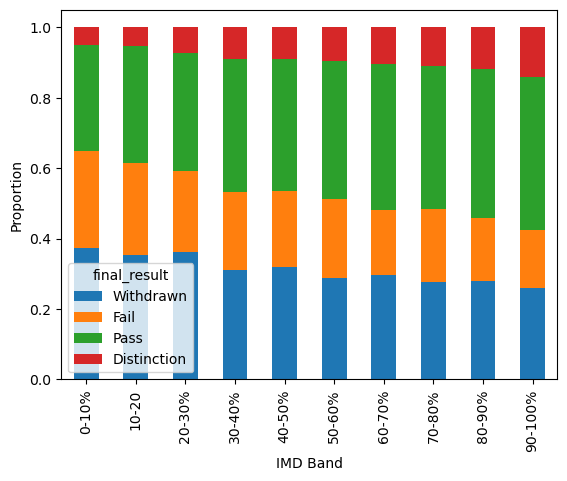

In [14]:
table.plot(
    kind='bar',
    stacked=True
)

plt.xlabel('IMD Band')
plt.ylabel('Proportion')
plt.show()

It is very clear that the higher the imd band the better students perform

<Axes: xlabel='imd_band', ylabel='region'>

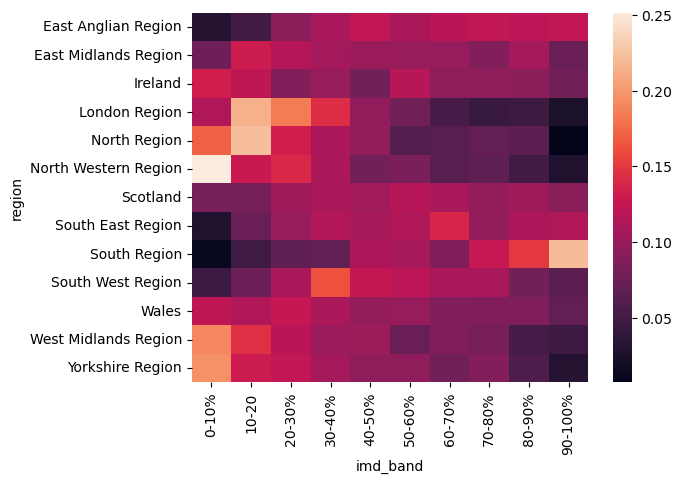

In [15]:
heatmap_data = pd.crosstab(
    data_assess['region'],
    data_assess['imd_band'],
    normalize='index'
)

sns.heatmap(heatmap_data)

In [16]:
table = pd.crosstab(
    data_assess['gender'],data_assess['final_result'],
    normalize='index'
)

table = table[['Withdrawn', 'Fail', 'Pass', 'Distinction']]
table

final_result,Withdrawn,Fail,Pass,Distinction
gender,,,,
F,0.304797,0.210830,0.389659,0.094714
M,0.317203,0.220923,0.370685,0.091189


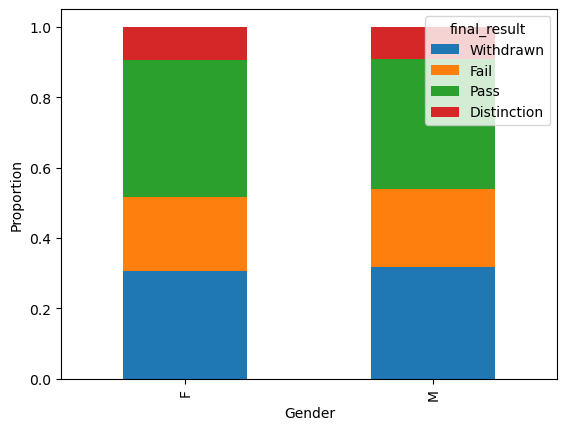

In [17]:
table.plot(
    kind='bar',
    stacked=True
)

plt.xlabel('Gender')
plt.ylabel('Proportion')
plt.show()

Gender has effectively 0 effect on the outcome

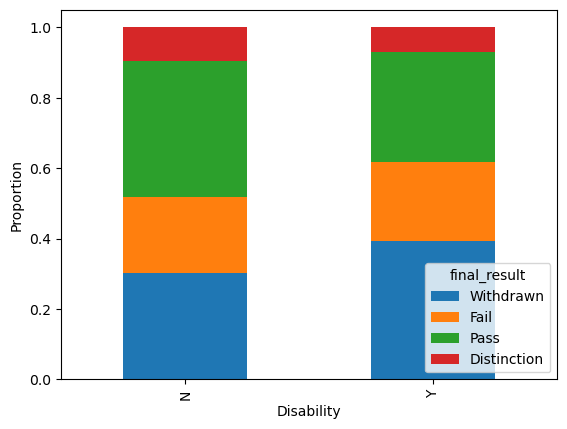

In [18]:
table = pd.crosstab(
    data_assess['disability'],data_assess['final_result'],
    normalize='index'
)

table = table[['Withdrawn', 'Fail', 'Pass', 'Distinction']]
table.plot(
    kind='bar',
    stacked=True
)

plt.xlabel('Disability')
plt.ylabel('Proportion')
plt.show()

In [19]:
table = pd.crosstab(
    data_assess['disability'],data_assess['final_result']
)

table = table[['Withdrawn', 'Fail', 'Pass', 'Distinction']]
table

final_result,Withdrawn,Fail,Pass,Distinction
disability,,,,
N,8911,6340,11377,2801
Y,1245,712,984,223


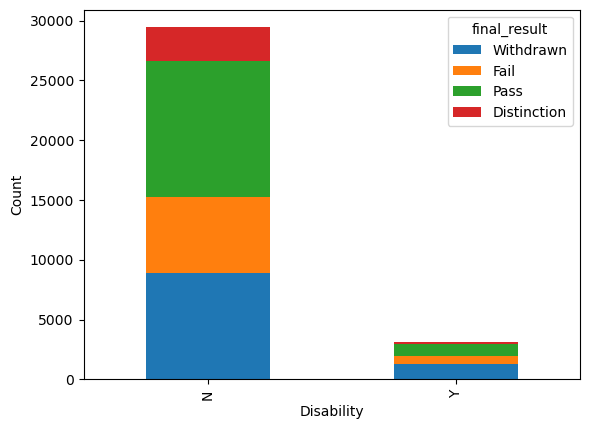

In [20]:
table.plot(
    kind='bar',
    stacked=True
)

plt.xlabel('Disability')
plt.ylabel('Count')
plt.show()

The data shows us that disability does seem to affect passing outcome but it is important to note that the number of people with disabilities is disproportionately smaller

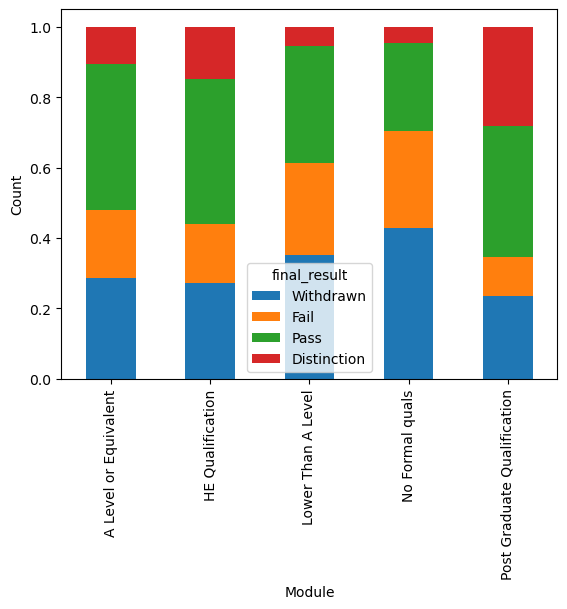

In [21]:
table = pd.crosstab(
    data_assess['highest_education'],data_assess['final_result'],
    normalize='index'
)

table = table[['Withdrawn', 'Fail', 'Pass', 'Distinction']]

table.plot(
    kind='bar',
    stacked=True
)

plt.xlabel('Module')
plt.ylabel('Count')
plt.show()

The more education a person has the less likely they are to fail or dropout

# Table 2 Student Registration

In [22]:
data_reg = pd.read_csv("anonymisedData/studentRegistration.csv")

In [23]:
data_reg.shape

(32593, 5)

In [24]:
data_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   code_module          32593 non-null  object 
 1   code_presentation    32593 non-null  object 
 2   id_student           32593 non-null  int64  
 3   date_registration    32548 non-null  float64
 4   date_unregistration  10072 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 1.2+ MB


In [25]:
data_reg.isnull().sum()

code_module                0
code_presentation          0
id_student                 0
date_registration         45
date_unregistration    22521
dtype: int64

In [26]:
data_reg[['date_registration', 'date_unregistration']].corr()

,date_registration,date_unregistration
date_registration,1.000000,0.253589
date_unregistration,0.253589,1.000000


# Data Filteration

Low correlation shows that required data cannot be extrapolated

In [27]:
data_filtered = data_assess[data_assess["code_module"]=="BBB"].copy()

In [28]:
data_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7909 entries, 748 to 8656
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   code_module           7909 non-null   object 
 1   code_presentation     7909 non-null   object 
 2   id_student            7909 non-null   int64  
 3   gender                7909 non-null   object 
 4   region                7909 non-null   object 
 5   highest_education     7909 non-null   object 
 6   imd_band              7846 non-null   object 
 7   age_band              7909 non-null   object 
 8   num_of_prev_attempts  7909 non-null   int64  
 9   studied_credits       7909 non-null   int64  
 10  disability            7909 non-null   object 
 11  final_result          7909 non-null   object 
 12  imd_num               7846 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 865.0+ KB


In [29]:
data_filtered['at_risk'] = data_filtered['final_result'].map({
    'Withdrawn': 1,
    'Fail': 1,
    'Pass': 0,
    'Distinction': 0
})

In [30]:
data_filtered

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,imd_num,at_risk
748,BBB,2013B,23629,F,East Anglian Region,Lower Than A Level,20-30%,0-35,2,60,N,Fail,2.0,1
749,BBB,2013B,25107,F,East Anglian Region,Lower Than A Level,20-30%,0-35,0,120,N,Pass,2.0,0
750,BBB,2013B,27891,M,Scotland,Lower Than A Level,0-10%,0-35,2,120,Y,Withdrawn,0.0,1
751,BBB,2013B,29144,M,South Region,Lower Than A Level,60-70%,0-35,0,120,N,Fail,6.0,1
752,BBB,2013B,31663,M,North Region,A Level or Equivalent,30-40%,35-55,0,60,N,Pass,3.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8652,BBB,2014J,2692969,F,Scotland,HE Qualification,80-90%,35-55,0,75,N,Pass,8.0,0
8653,BBB,2014J,2694919,F,East Anglian Region,Lower Than A Level,60-70%,35-55,0,120,Y,Pass,6.0,0
8654,BBB,2014J,2698577,F,Wales,Lower Than A Level,50-60%,35-55,0,60,N,Fail,5.0,1
8655,BBB,2014J,2698588,F,Yorkshire Region,HE Qualification,30-40%,0-35,0,120,N,Distinction,3.0,0
